<a href="https://colab.research.google.com/github/veapasichnyk/HomeWorksDataLovesAcademy/blob/main/HW_2_5_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

In [1]:
# Імпорт бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [2]:
df = pd.read_csv("train.csv")

In [3]:
# Перетворення колонки 'date' у формат datetime
df['date'] = pd.to_datetime(df['date'])

In [4]:
# Встановлення 'date' як індекс
df.set_index('date', inplace=True)

In [5]:
# Вивід перших 10 рядків
print(df.head(10))

            store  item  sales
date                          
2013-01-01      1     1     13
2013-01-02      1     1     11
2013-01-03      1     1     14
2013-01-04      1     1     13
2013-01-05      1     1     10
2013-01-06      1     1     12
2013-01-07      1     1     10
2013-01-08      1     1      9
2013-01-09      1     1     12
2013-01-10      1     1      9


In [6]:
# Інформація про датафрейм
print("\nІнформація про датафрейм:")
print(df.info())


Інформація про датафрейм:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB
None


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



In [7]:
# список для збереження item_id та його середнього розкиду
spread_stats = []

# Проходимо по кожному айтему
for item_id in df["item"].unique():
    # Фільтруємо дані лише для цього айтема
    item_df = df[df["item"] == item_id].reset_index()

    # Робимо "wide" таблицю: index = date, columns = store, values = sales
    wide = item_df.pivot_table(index='date', columns='store', values='sales')

    # Розрахунок довірчого інтервалу 95%: 97.5-й квантиль - 2.5-й квантиль
    low_ci = wide.quantile(0.025, axis=1)
    high_ci = wide.quantile(0.975, axis=1)
    ci_width = high_ci - low_ci

    # Обчислюємо середню ширину CI по всіх датах
    avg_ci_width = ci_width.mean()

    # Зберігаємо результат
    spread_stats.append((item_id, avg_ci_width))

In [8]:
# Формуємо датафрейм і сортуємо
spread_df = pd.DataFrame(spread_stats, columns=["item", "avg_CI_width"]).sort_values(by="avg_CI_width", ascending=False)

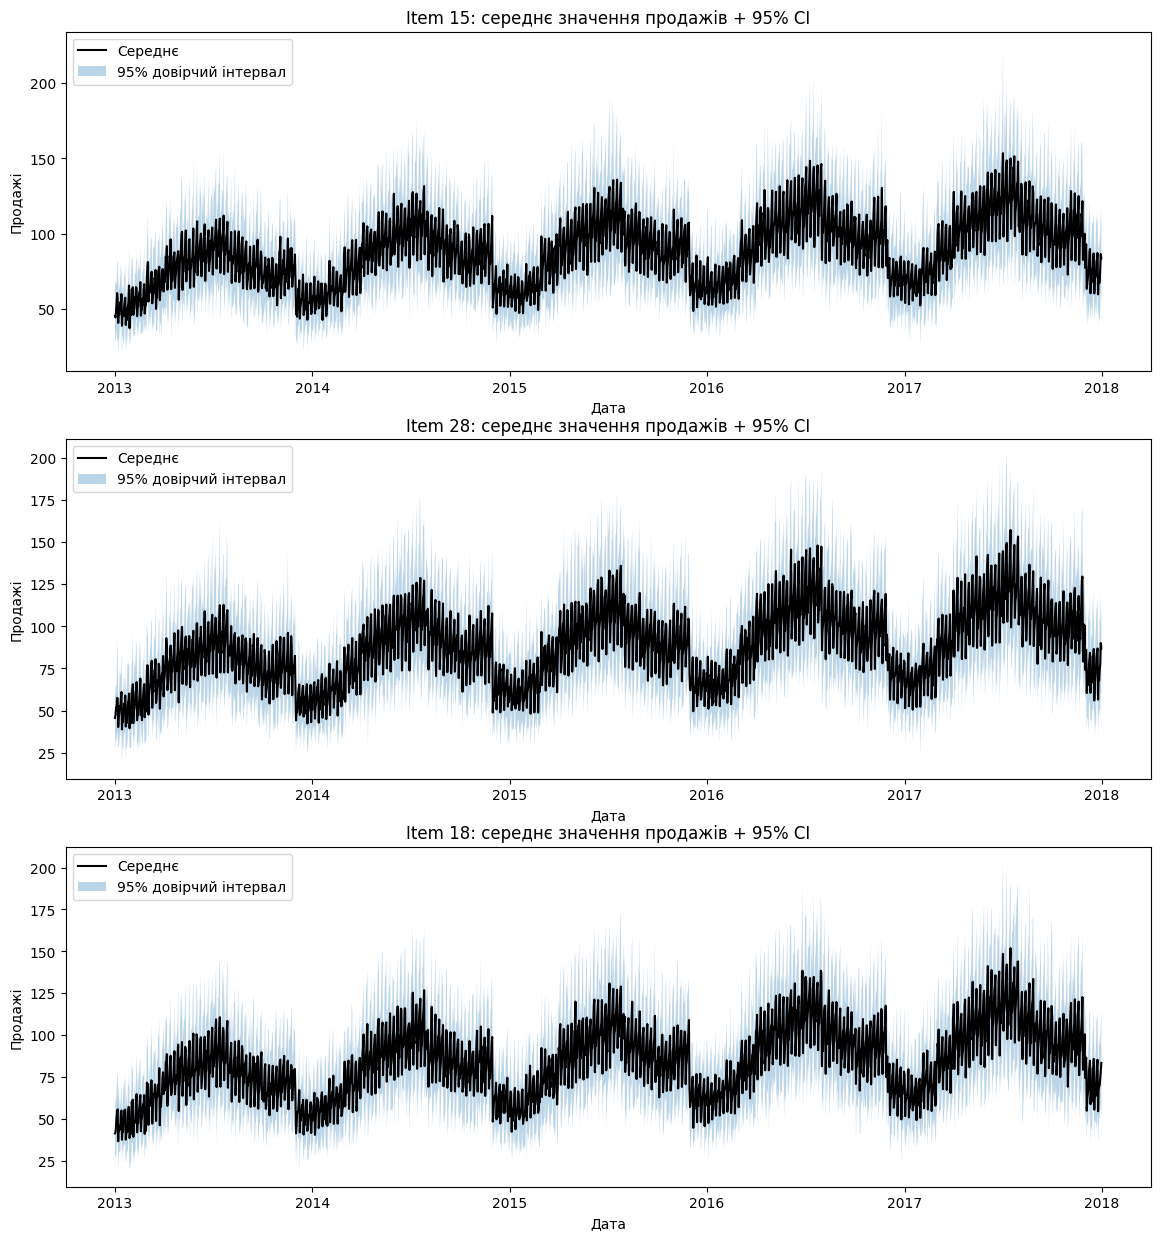

In [9]:
# Побудуємо графіки для 3 айтемів з найбільшим розкидом (найширший 95% CI між магазинами)

# Візьмемо топ-3 айтеми
top_items = spread_df.head(3)["item"].tolist()

plt.figure(figsize=(14, 5 * len(top_items)))

for i, item_id in enumerate(top_items, 1):
    item_df = df[df['item'] == item_id].reset_index()
    wide = item_df.pivot_table(index='date', columns='store', values='sales')

    mean_series = wide.mean(axis=1)
    low_ci = wide.quantile(0.025, axis=1)
    high_ci = wide.quantile(0.975, axis=1)

    # Видаляємо NaN і перетворюємо на float64
    plot_df = pd.DataFrame({
        "date": wide.index,
        "mean": mean_series,
        "low": low_ci,
        "high": high_ci
    }).dropna()

    dates = plot_df["date"].values
    mean_vals = plot_df["mean"].astype(np.float64).values
    low_vals = plot_df["low"].astype(np.float64).values
    high_vals = plot_df["high"].astype(np.float64).values

    plt.subplot(len(top_items), 1, i)
    plt.plot(dates, mean_vals, label="Середнє", color="black")
    plt.fill_between(dates, low_vals, high_vals, alpha=0.3, label="95% довірчий інтервал")
    plt.title(f"Item {item_id}: середнє значення продажів + 95% CI")
    plt.xlabel("Дата")
    plt.ylabel("Продажі")
    plt.legend()


**Спостереження**

1. Яскраво виражена сезонність

Усі три айтеми мають чітку річну циклічність - приблизно 6 піків на 5 років, що вказує на щорічні хвилі попиту. Це може бути пов’язано з сезонними кампаніями, святами, погодою або іншими факторами.

2. Сильна варіативність між магазинами

Ширина заштрихованого 95% довірчого інтервалу в усіх айтемів досить велика, особливо в періоди пікових продажів. Це означає, що одні й ті самі товари мають дуже різні рівні попиту в різних магазинах. Можливо, це пов’язано з регіональними відмінностями, демографією, конкурентами чи маркетингом.

3. Зростання попиту з часом

Загальний рівень середніх продажів з 2013 по 2017 поступово підвищується. Це може означати успішну стратегію масштабування, розвиток мережі магазинів або популяризацію товарів.

Цікаво подивитись на 3 айтеми з найменшим розкидом (тобто найбільш стабільні продажі по магазинах).

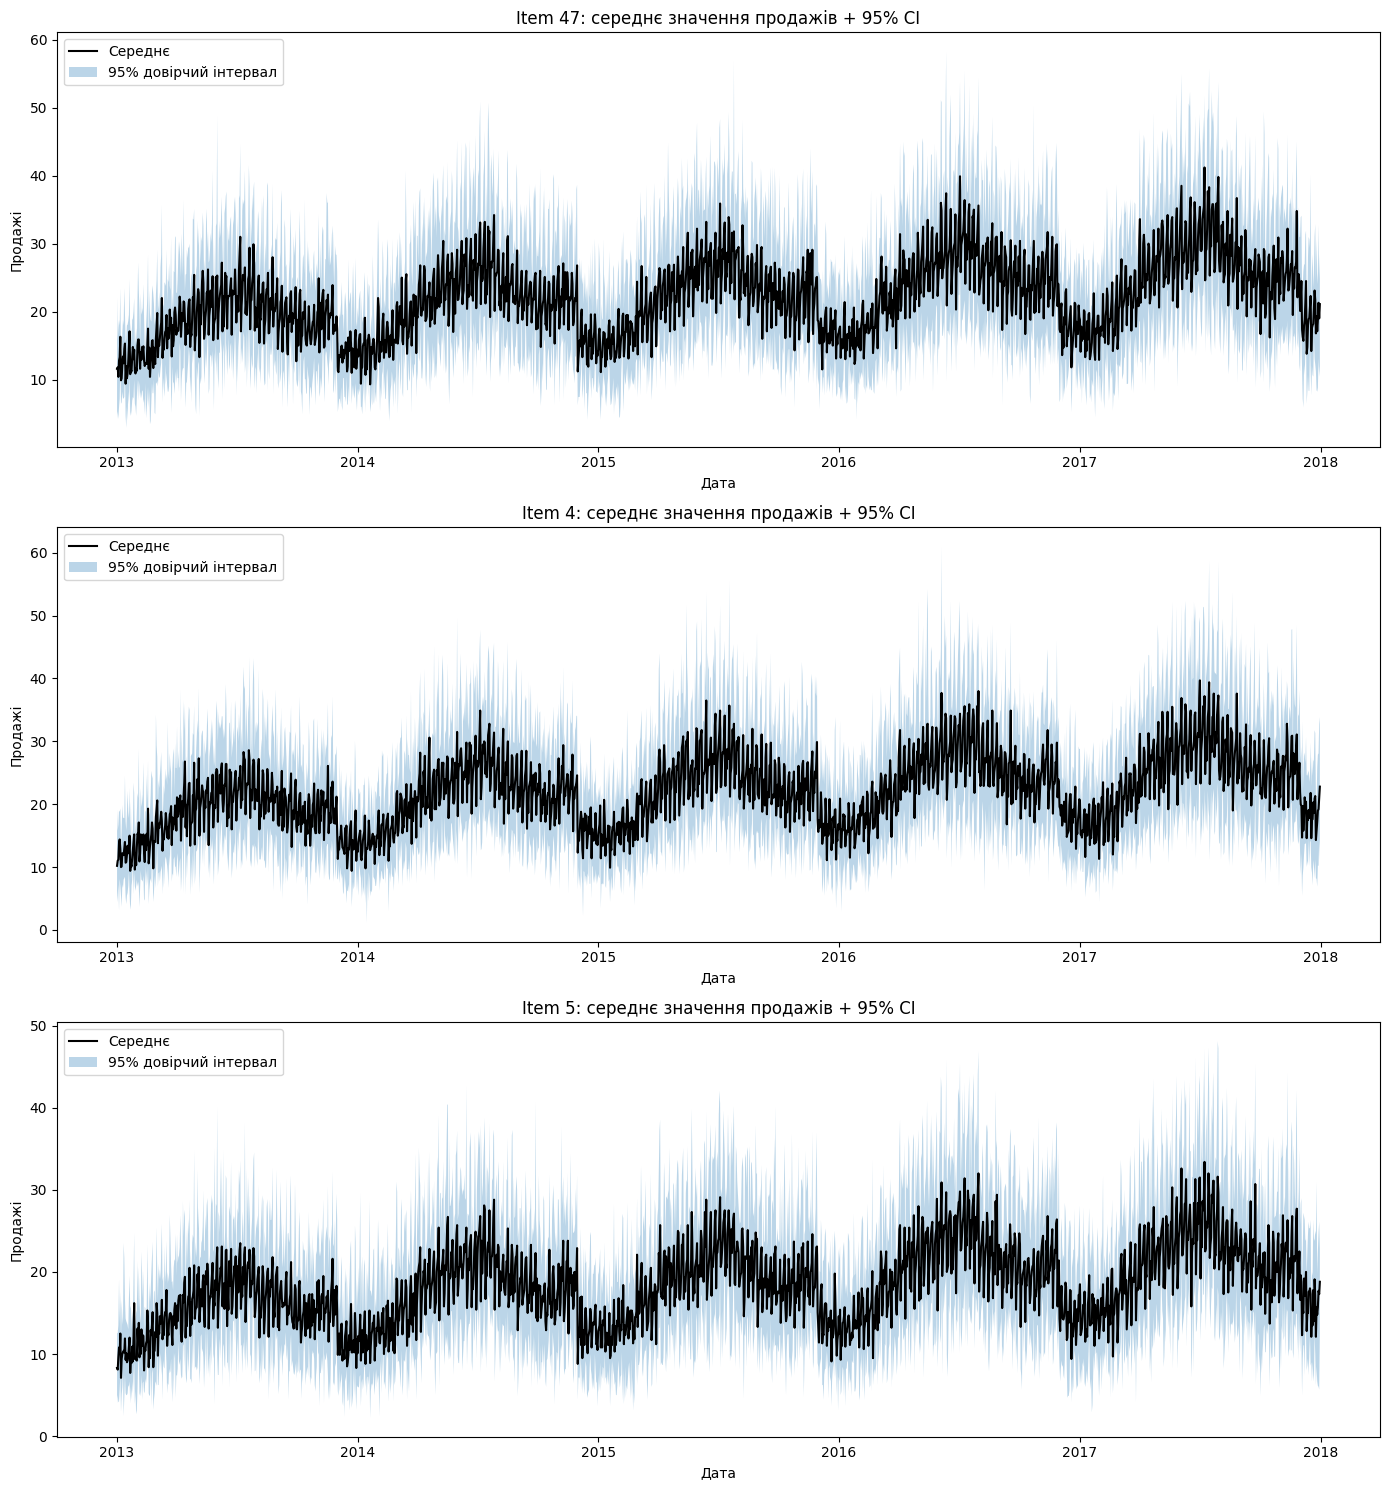

In [10]:
# Побудова графіків для айтемів з найменшим розкидом
bottom_items = spread_df.tail(3)["item"].tolist()

plt.figure(figsize=(14, 5 * len(bottom_items)))

for i, item_id in enumerate(bottom_items, 1):

    item_df = df[df['item'] == item_id].reset_index()
    wide = item_df.pivot_table(index='date', columns='store', values='sales')

    mean_series = wide.mean(axis=1)
    low_ci = wide.quantile(0.025, axis=1)
    high_ci = wide.quantile(0.975, axis=1)

    plot_df = pd.DataFrame({
        "date": wide.index,
        "mean": mean_series,
        "low": low_ci,
        "high": high_ci
    }).dropna()

    dates = plot_df["date"].values
    mean_vals = plot_df["mean"].astype(np.float64).values
    low_vals = plot_df["low"].astype(np.float64).values
    high_vals = plot_df["high"].astype(np.float64).values

    plt.subplot(len(bottom_items), 1, i)
    plt.plot(dates, mean_vals, label="Середнє", color="black")
    plt.fill_between(dates, low_vals, high_vals, alpha=0.3, label="95% довірчий інтервал")
    plt.title(f"Item {item_id}: середнє значення продажів + 95% CI")
    plt.xlabel("Дата")
    plt.ylabel("Продажі")
    plt.legend()

plt.tight_layout()
plt.show()

**Спостереження**

1. Виражена сезонність

Кожен айтем має річну циклічність із кількома чіткими піками на рік. Тренди особливо виразні в Item 4 та Item 5 - сплески продажів відбуваються майже на одних і тих самих відрізках року.

2. Помірний розкид (довірчий інтервал)

На відміну від найнестабільніших айтемів (наприклад, Item 15), тут довірчий інтервал вужчий, але все ще помітний. Це вказує на невеликі, але стабільні відмінності між магазинами - деякі магазини продають ці айтеми активніше, інші - трохи слабше.

3. Ріст продажів у перші роки

Спостерігається зростання базового рівня продажів до 2015–2016 року, а далі - певна стабілізація або навіть спад. Це може бути наслідком ринкової насиченості або стабілізації попиту.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

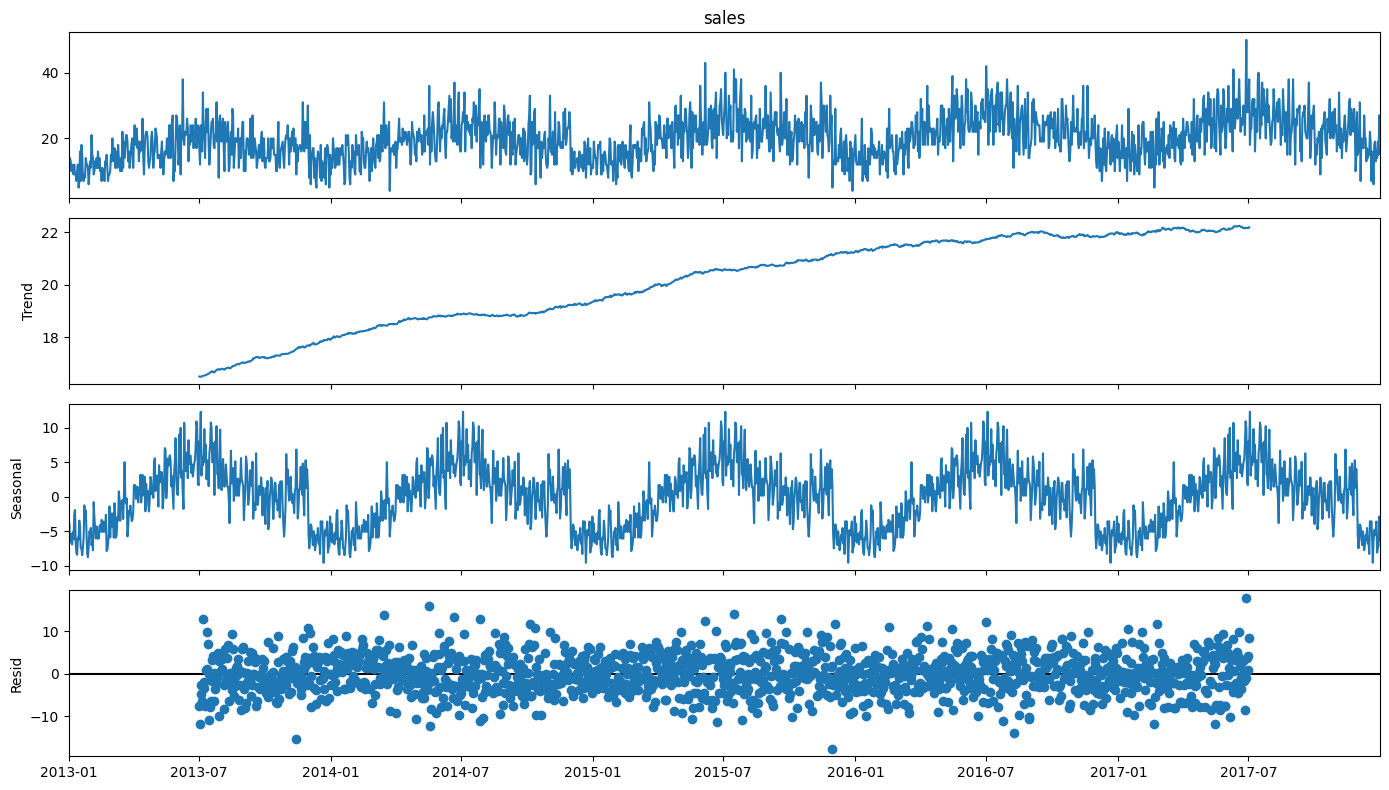

In [11]:
# Вибірка даних для item == 1 і store == 1
ts = df[(df['item'] == 1) & (df['store'] == 1)].sort_index()['sales']

# Переконуємось, що дані щоденні та без пропусків
# Якщо потрібно - ресемплюємо на щоденну частоту та заповнюємо пропуски
ts = ts.resample('D').sum().fillna(0)

# Декомпозиція адитивної моделі
decomposition = seasonal_decompose(ts, model='additive', period=365)  # річна сезонність

# Візуалізація компонент
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

**Спостереження**

1. Продажі (sales)

Помітна нерегулярна варіативність, але середній рівень поступово зростає.
Є періодичні коливання, які виглядають як сезонні.

2. Тренд (trend)

Чітке поступове зростання з 2013 до 2016 року. У 2017 році тренд вирівнюється, можливе насичення попиту.

3. Сезонність (seasonal)

Чітко помітна річна сезонність (оскільки period=365). Кожного року є піки та спади в одні й ті ж місяці - можливо, пов’язано з сезоном, акціями або святами.

4. Залишки (resid)

Розкидані навколо нуля, деякі відхилення значні - вплив випадкових факторів.

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [12]:
pip install -q "u8darts[all]"

In [13]:
from darts import TimeSeries

In [14]:
# Створення об'єкта TimeSeries тільки для 'sales'
ts_darts = TimeSeries.from_series(ts)

# Перевірка
print(ts_darts)

<TimeSeries (DataArray) (date: 1826, component: 1, sample: 1)> Size: 15kB
array([[[13.]],

       [[11.]],

       [[14.]],

       ...,

       [[15.]],

       [[27.]],

       [[23.]]])
Coordinates:
  * date       (date) datetime64[ns] 15kB 2013-01-01 2013-01-02 ... 2017-12-31
  * component  (component) object 8B 'sales'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None


5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

In [15]:
# Розбиваємо з урахуванням включеної дати '2017-10-01'
split_date = pd.Timestamp("2017-10-01")

train, val = ts_darts.split_before(split_date)

<Axes: xlabel='date'>

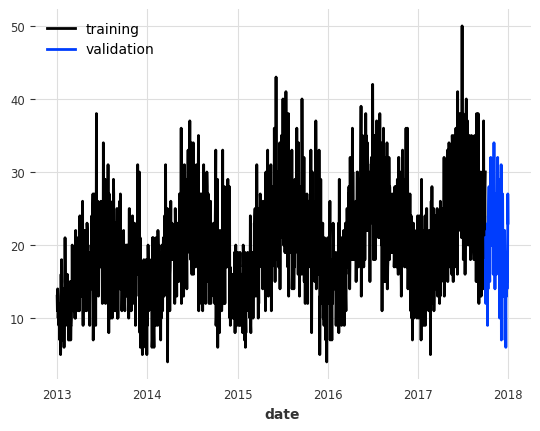

In [16]:
train.plot(label="training")
val.plot(label="validation")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1000x500 with 0 Axes>

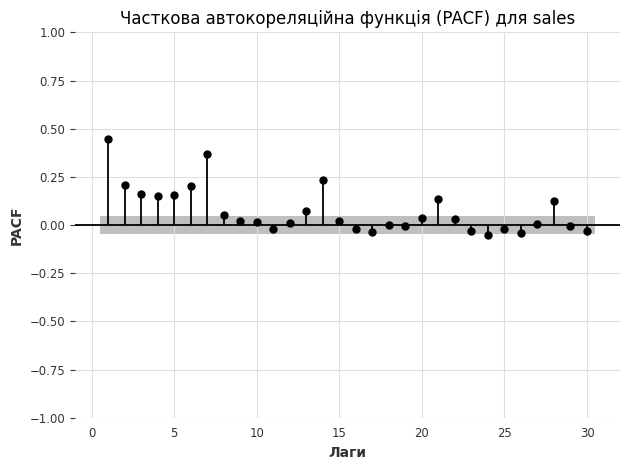

In [17]:
# Побудова PACF
plt.figure(figsize=(10, 5))
plot_pacf(ts, lags=30, method='ywm', zero=False)
plt.title("Часткова автокореляційна функція (PACF) для sales")
plt.xlabel("Лаги")
plt.ylabel("PACF")
plt.tight_layout()
plt.show()

**Спостереження**

Найсильніші та статистично значущі лаги: 1, 2, 3, 4, 7, 8.

Починаючи з лага 10 - значущість або зникає, або одиничні стрибки виглядають як шум.

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [18]:
from darts.utils.statistics import check_seasonality

# Визначення сезонності в тренувальному ряді
is_seasonal, seasonality_period = check_seasonality(train, max_lag=400, alpha=0.05)

print("Чи є сезонність:", is_seasonal)
print("Період сезонності:", seasonality_period)

Чи є сезонність: True
Період сезонності: 7


**Спостереження**

Період сезонності: 7

Це означає, що є щотижнева сезонність - повторювані патерни кожні 7 днів.

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

In [19]:
from darts.models import NaiveSeasonal, NaiveDrift

# Побудова моделей
model_seasonal = NaiveSeasonal(K=7)
model_drift = NaiveDrift()

model_seasonal.fit(train)
forecast_seasonal = model_seasonal.predict(len(val))

model_drift.fit(train)
forecast_drift = model_drift.predict(len(val))

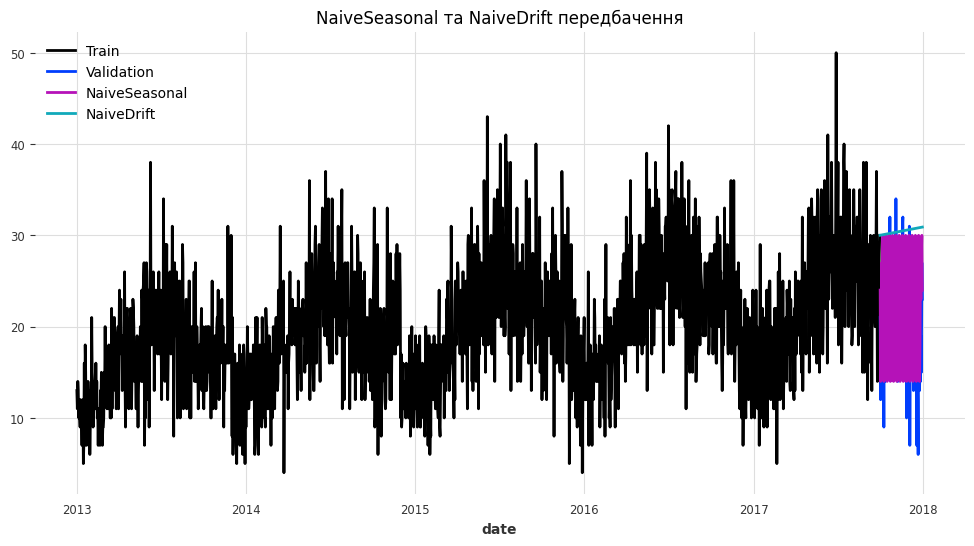

In [20]:
# Візуалізація
plt.figure(figsize=(12, 6))
train.plot(label="Train")
val.plot(label="Validation")
forecast_seasonal.plot(label="NaiveSeasonal")
forecast_drift.plot(label="NaiveDrift")
plt.title("NaiveSeasonal та NaiveDrift передбачення")
plt.legend()
plt.show()

**Спостереження**

1. Сезонність чітко врахована моделлю NaiveSeasonal:

Прогноз NaiveSeasonal (фіолетовий) має характерні щоденні коливання, які повторюють структуру останніх 7 днів з тренування. Це узгоджується з виявленим періодом сезонності = 7 (тиждень), але він не реагує на загальний тренд.

2. NaiveDrift (блакитний) враховує тільки тренд:

Ця модель проводить умовну лінію зростання, не реагуючи на сезонні зміни.

3. Якість прогнозу:

Жодна з моделей не дає дуже точного передбачення

Можна спробувати підготувати менш шумний ряд, на якому NaiveDrift зможе дати кращий прогноз

- Агрегувати до тижнів
- Застосувати ковзне середнє перед прогнозом.

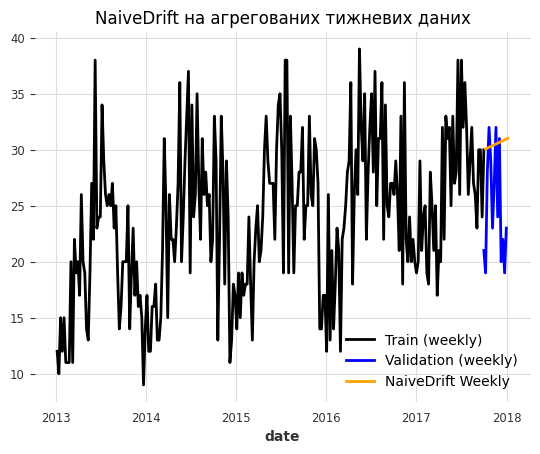

In [21]:
# Агрегація до тижнів
weekly_train = train.resample('W')
weekly_val = val.resample('W')

# Навчання та прогноз
model_weekly = NaiveDrift()
model_weekly.fit(weekly_train)
forecast_weekly = model_weekly.predict(len(weekly_val))

# Візуалізація
weekly_train.plot(label="Train (weekly)", color='black')
weekly_val.plot(label="Validation (weekly)", color='blue')
forecast_weekly.plot(label="NaiveDrift Weekly", color='orange')
plt.title("NaiveDrift на агрегованих тижневих даних")
plt.show()

In [22]:
# Отримуємо масив значень
values = train.values().flatten()

# Обчислюємо ковзне середнє (наприклад, вікно 7)
window_size = 7
smoothed_values = np.convolve(values, np.ones(window_size)/window_size, mode='valid')

# Створюємо новий TimeSeries зі згладженими значеннями
smoothed_time_index = train.time_index[window_size - 1:]
smoothed_series = TimeSeries.from_times_and_values(smoothed_time_index, smoothed_values)

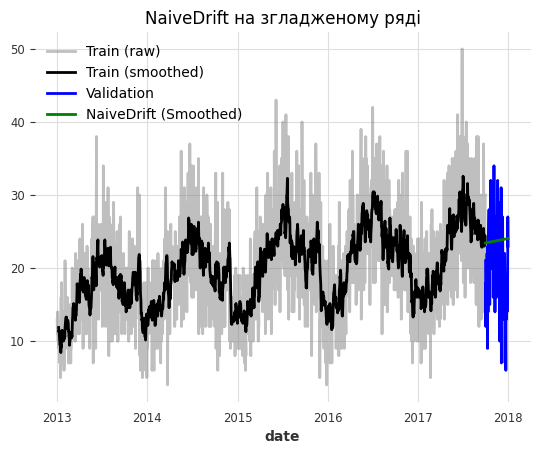

In [23]:
model_smooth = NaiveDrift()
model_smooth.fit(smoothed_series)
forecast_smooth = model_smooth.predict(len(val))

# Візуалізація
train.plot(label="Train (raw)", color='gray', alpha=0.5)
smoothed_series.plot(label="Train (smoothed)", color='black')
val.plot(label="Validation", color='blue')
forecast_smooth.plot(label="NaiveDrift (Smoothed)", color='green')
plt.title("NaiveDrift на згладженому ряді")
plt.show()

In [25]:
# Комбінований прогноз (усереднення)
combined_forecast = (forecast_seasonal + forecast_drift) / 2

In [26]:
alpha = 0.7  # 70% сезонність, 30% тренд
combined = forecast_seasonal * alpha + forecast_drift * (1 - alpha)

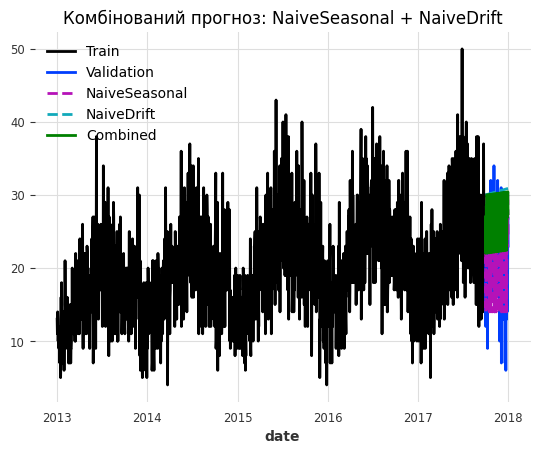

In [27]:
train.plot(label="Train", lw=2)
val.plot(label="Validation", lw=2)
forecast_seasonal.plot(label="NaiveSeasonal", linestyle='--')
forecast_drift.plot(label="NaiveDrift", linestyle='--')
combined_forecast.plot(label="Combined", color='green', lw=2)
plt.title("Комбінований прогноз: NaiveSeasonal + NaiveDrift")
plt.legend()
plt.show()

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [29]:
from darts.metrics import mape

# MAPE для NaiveSeasonal
mape_seasonal = mape(val, forecast_seasonal)
print(f"MAPE (NaiveSeasonal): {mape_seasonal:.2f}%")

# MAPE для NaiveDrift
mape_drift = mape(val, forecast_drift)
print(f"MAPE (NaiveDrift): {mape_drift:.2f}%")

# MAPE для комбінованого прогнозу (усереднення)
combined_forecast = (forecast_seasonal + forecast_drift) / 2
mape_combined = mape(val, combined_forecast)
print(f"MAPE (Combined Forecast): {mape_combined:.2f}%")

MAPE (NaiveSeasonal): 38.17%
MAPE (NaiveDrift): 68.74%
MAPE (Combined Forecast): 49.11%


**Спостереження**

- NaiveSeasonal - найкраща наївна модель для цього ряду, що логічно: ми раніше виявили щотижневу сезональність (період = 7).

- NaiveDrift має дуже велику помилку, бо чутливий до шуму.

- Комбінування прогнозів допомогло зменшити помилку Drift, але все одно гірше, ніж просто Seasonal.

10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [30]:
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import XGBModel
from darts.metrics import mape
from darts.utils.missing_values import fill_missing_values

In [31]:
# Розширений діапазон коваріатів
covariates = datetime_attribute_timeseries(
    pd.date_range(start="2013-01-01", end="2017-12-31", freq="D"),
    attribute="dayofweek",
    one_hot=True
)

# Масштабуємо
scaler = Scaler()
covariates_scaled = scaler.fit_transform(covariates)

# Розділяємо на train і val, але val починається з 2017-09-24 (не 2017-10-01!)
cov_train = covariates_scaled.slice_intersect(train)

# Розширюємо cov_val на 7 днів назад
cov_val = covariates_scaled.slice(pd.Timestamp("2017-09-24"), pd.Timestamp("2017-12-31"))

In [32]:
# Побудова моделі
xgb_model = XGBModel(
    lags=14,
    lags_past_covariates=[-7, -1],
    output_chunk_length=len(val),
    random_state=42
)

In [33]:
# Навчання
xgb_model.fit(train, past_covariates=cov_train)
forecast_xgb = xgb_model.predict(len(val), past_covariates=cov_val)

In [34]:
# MAPE
xgb_mape = mape(val, forecast_xgb)
print(f"MAPE (XGBModel): {xgb_mape:.2f}%")

MAPE (XGBModel): 30.65%


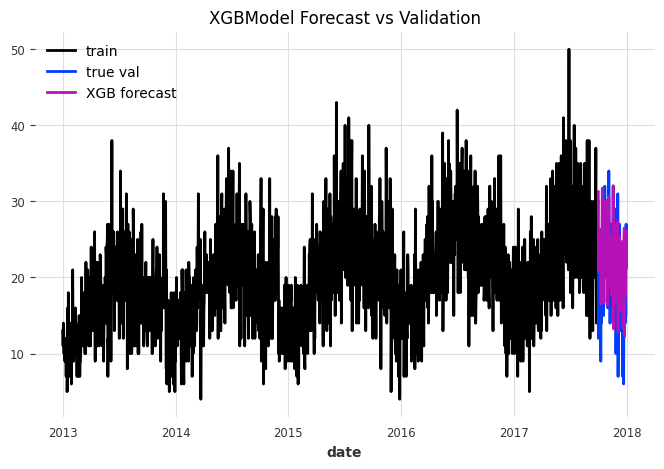

In [35]:
# Візуалізація
plt.figure(figsize=(8, 5))
train.plot(label="train")
val.plot(label="true val")
forecast_xgb.plot(label="XGB forecast")
plt.title("XGBModel Forecast vs Validation")
plt.legend()
plt.show()

**Спостереження**

Тренд і амплітуди XGBModel загалом схожі на справжні дані. Є легка недооцінка піків.

MAPE = 30.65% підтверджує, що модель уже помітно краща за наївні.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [36]:
from darts.models import ExponentialSmoothing

In [37]:
# Тренування моделі
es_model = ExponentialSmoothing(seasonal_periods=7)  # ми виявили сезонність = 7
es_model.fit(train)

ExponentialSmoothing(trend=ModelMode.ADDITIVE, damped=False, seasonal=SeasonalityMode.ADDITIVE, seasonal_periods=7, random_state=None, kwargs=None)

In [38]:
# Прогноз на період валідації
forecast_es = es_model.predict(len(val))

In [39]:
#Обчислюємо MAPE
mape_es = mape(val, forecast_es)
print(f"MAPE (ExponentialSmoothing): {mape_es:.2f}%")

MAPE (ExponentialSmoothing): 39.01%


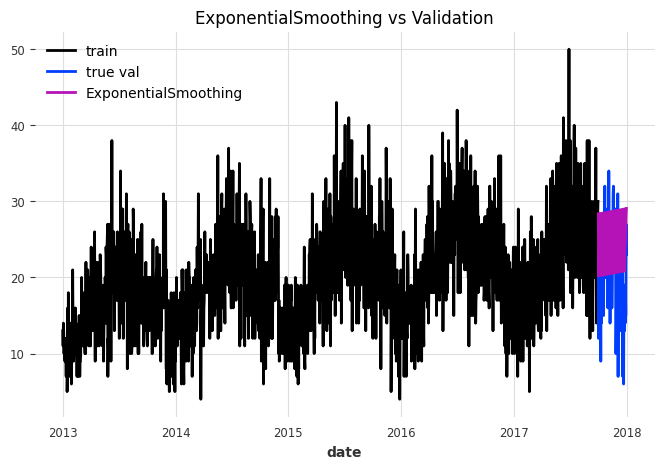

In [40]:
# Візуалізація
plt.figure(figsize=(8, 5))
train.plot(label="train")
val.plot(label="true val")
forecast_es.plot(label="ExponentialSmoothing")
plt.title("ExponentialSmoothing vs Validation")
plt.legend()
plt.show()

**Спостереження**

MAPE: 39.01%

Модель тримає загальний рівень і сезонність, але недостатньо добре реагує на різкі коливання у продажах. Прогноз гладкий, що часто характерно для експоненційного згладжування.

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

In [41]:
from darts.models import ARIMA

In [42]:
# Тренування моделі
arima_model = ARIMA()
arima_model.fit(train)

ARIMA(p=12, d=1, q=0, seasonal_order=(0, 0, 0, 0), trend=None, random_state=None, add_encoders=None)

In [43]:
# Прогноз
forecast_arima = arima_model.predict(len(val))

In [44]:
# MAPE
mape_arima = mape(val, forecast_arima)
print(f"MAPE (ARIMA): {mape_arima:.2f}%")

MAPE (ARIMA): 39.49%


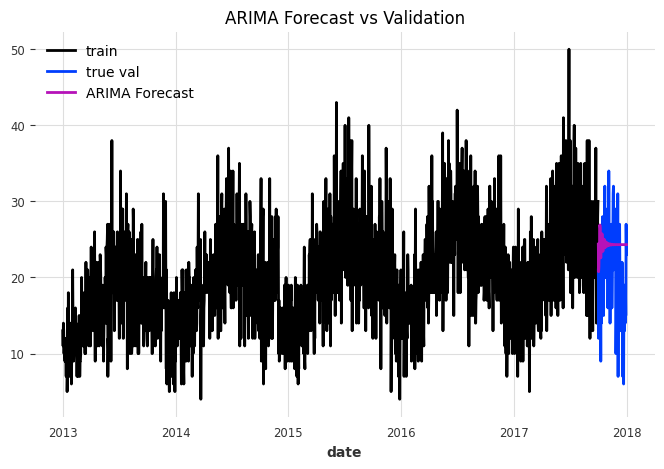

In [45]:
# Візуалізація
plt.figure(figsize=(8, 5))
train.plot(label="train")
val.plot(label="true val")
forecast_arima.plot(label="ARIMA Forecast")
plt.title("ARIMA Forecast vs Validation")
plt.legend()
plt.show()

**Спостереження**

MAPE=39.49%

Прогноз ARIMA дещо згладжений, і не відтворює піки/впади так детально, як інші моделі.

Він не захоплює сезонні коливання, на відміну від моделей, що явно використовують сезонність (NaiveSeasonal, ExponentialSmoothing)


13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [46]:
from darts.models import AutoARIMA

In [60]:
# Ініціалізація AutoARIMA
aarima = AutoARIMA(
    trace=True,            # показує перебір моделей
    season_length=7,       # тижнева сезонність
    add_encoders=None,     # без енкодерів
    random_state=42
)

In [62]:
# Навчання
aarima.fit(train)


ARIMA(2,1,2)(1,0,1)[7] with drift        :inf

ARIMA(0,1,0) with drift        :11699.318946383404

ARIMA(1,1,0)(1,0,0)[7] with drift        :11207.06550013974

ARIMA(0,1,1)(0,0,1)[7] with drift        :10659.54083761185

ARIMA(0,1,0)                   :11697.3176603854

ARIMA(0,1,1) with drift        :10763.389108968566

ARIMA(0,1,1)(1,0,1)[7] with drift        :inf

ARIMA(0,1,1)(0,0,2)[7] with drift        :10587.221751657391

ARIMA(0,1,1)(1,0,2)[7] with drift        :inf

ARIMA(0,1,0)(0,0,2)[7] with drift        :11549.283365315592

ARIMA(1,1,1)(0,0,2)[7] with drift        :10580.668461802417

ARIMA(1,1,1)(0,0,1)[7] with drift        :10652.964372234705

ARIMA(1,1,1)(1,0,2)[7] with drift        :inf

ARIMA(1,1,1)(1,0,1)[7] with drift        :inf

ARIMA(1,1,0)(0,0,2)[7] with drift        :11181.428138065276

ARIMA(2,1,1)(0,0,2)[7] with drift        :10579.074492145706

ARIMA(2,1,1)(0,0,1)[7] with drift        :10648.61347587876

ARIMA(2,1,1)(1,0,2)[7] with drift        :inf

ARIMA(2,

AutoARIMA(add_encoders=None, quantiles=None, random_state=42, trace=True, season_length=7)

**Оптимальна модель**

order = (4, 1, 1) — це p=4, d=1, q=1

seasonal_order = (0, 0, 2, 7) — тобто P=0, D=0, Q=2, s=7 (сезонність = 7 днів)

Найнижче значення AIC: 10574.48

drift = False (останній варіант був без дрейфу і краще за версії з with drift)

In [63]:
# Прогноз
forecast_aarima = aarima.predict(len(val))

In [64]:
# Оцінка якості
mape_aarima = mape(val, forecast_aarima)
print(f"MAPE (AutoARIMA): {mape_aarima:.2f}%")

MAPE (AutoARIMA): 40.56%


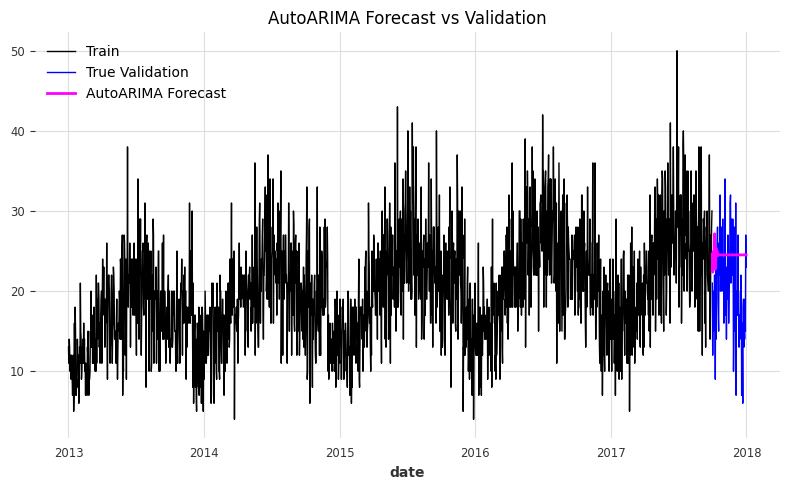

In [65]:
plt.figure(figsize=(8, 5))
train.plot(label="Train", lw=1, color="black")
val.plot(label="True Validation", lw=1, color="blue")
forecast_aarima.plot(label="AutoARIMA Forecast", lw=2, color="magenta")
plt.title("AutoARIMA Forecast vs Validation")
plt.legend()
plt.tight_layout()
plt.show()

**Спостереження**

MAPE=40.56% - це поки що найгірший результат серед інших моделей.

Висновок з графіка:

- Прогноз досить згладжений.

- Не встигає за коливаннями справжніх значень.

14. Натренуйте модель Prophet та зробіть висновок про її якість.

In [66]:
from darts.models import Prophet

In [67]:
# Ініціалізація моделі Prophet
prophet_model = Prophet()

In [68]:
# Навчання на train
prophet_model.fit(train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpw8onwl3s/8ab1nr8y.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpw8onwl3s/983o_q4v.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=34180', 'data', 'file=/tmp/tmpw8onwl3s/8ab1nr8y.json', 'init=/tmp/tmpw8onwl3s/983o_q4v.json', 'output', 'file=/tmp/tmpw8onwl3s/prophet_modely2aea4_7/prophet_model-20250825134352.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:43:52 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:43:52 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Prophet(add_seasonalities=None, country_holidays=None, suppress_stdout_stderror=True, add_encoders=None, cap=None, floor=None, random_state=None)

In [69]:
# Прогнозуємо на довжину валідаційного періоду
forecast_prophet = prophet_model.predict(len(val))

In [70]:
mape_prophet = mape(val, forecast_prophet)
print(f"MAPE (Prophet): {mape_prophet:.2f}%")

MAPE (Prophet): 23.80%


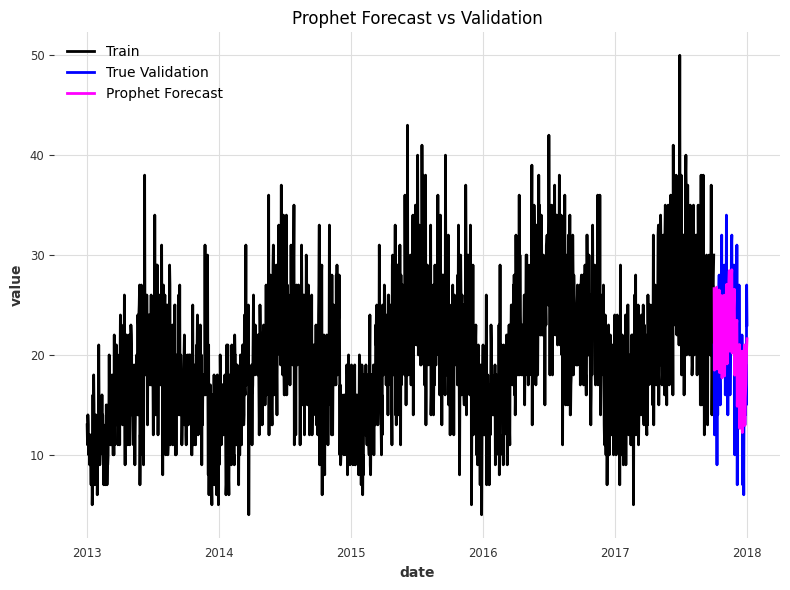

In [71]:
plt.figure(figsize=(8, 6))
train.plot(label="Train", color="black")
val.plot(label="True Validation", color="blue")
forecast_prophet.plot(label="Prophet Forecast", color="magenta")
plt.title("Prophet Forecast vs Validation")
plt.xlabel("date")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

**Спостереження**

Prophet показала найкращу якість прогнозу на валідаційному наборі серед усіх моделей, що підтверджується найнижчим значенням MAPE=23.80%.

Графік візуально також демонструє хорошу відповідність прогнозу реальним значенням: фіолетова лінія добре повторює тренд і сезонність синьої лінії.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [72]:
from darts.models import RNNModel

In [82]:
rnn_model = RNNModel(model='RNN', input_chunk_length=7, n_epochs=300)

In [83]:
rnn_model.fit(train)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | RNN              | 700    | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
726       Trainable params
0         Non-trainable params
726       Total params
0.003     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=300` reached.


RNNModel(model=RNN, hidden_dim=25, n_rnn_layers=1, dropout=0.0, training_length=24, input_chunk_length=7, n_epochs=300)

In [84]:
forecast_rnn = rnn_model.predict(len(val))

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

In [85]:
rnn_mape = mape(val, forecast_rnn)
print(f"MAPE (RNN): {rnn_mape:.2f}%")

MAPE (RNN): 34.29%


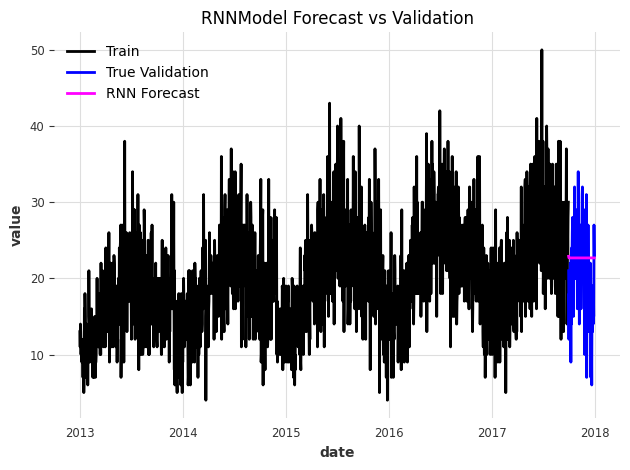

In [86]:
train.plot(label="Train", color="black")
val.plot(label="True Validation", color="blue")
forecast_rnn.plot(label="RNN Forecast", color="magenta")
plt.title("RNNModel Forecast vs Validation")
plt.ylabel("value")
plt.xlabel("date")
plt.legend()
plt.tight_layout()
plt.show()

**Спостереження**

RNN показує гіршу якість, ніж Prophet (23.8%) і XGB (30.65%), але кращу, ніж:ARIMA (39.5%), Exponential Smoothing (39.0%), AutoARIMA (40.6%)

Прогноз гладкий і згладжений - модель недооцінює піки і не дотримується сезонності, яку видно в реальних даних.

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [87]:
# Бектест: 30 днів прогнозу з кроком 30 днів, 12 кроків (приблизно 1 рік)
backtest = prophet_model.historical_forecasts(
    ts_darts,
    start=train.end_time() + pd.Timedelta(days=1),
    forecast_horizon=30,
    stride=30,
    retrain=True,
    verbose=True
)

historical forecasts:   0%|          | 0/3 [00:00<?, ?it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpw8onwl3s/q_dkkb27.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpw8onwl3s/kfha2x6u.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=68592', 'data', 'file=/tmp/tmpw8onwl3s/q_dkkb27.json', 'init=/tmp/tmpw8onwl3s/kfha2x6u.json', 'output', 'file=/tmp/tmpw8onwl3s/prophet_modelso41qpva/prophet_model-20250825145037.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:50:37 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:50:37 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
historical forecasts:  33%|███▎      | 1/3 [00:00<00:00,  3.00it/s]INFO:prophet:Dis

In [89]:
# Обчислення MAPE
backtest_mape = mape(ts_darts.slice_intersect(backtest), backtest)
print(f"Backtest MAPE: {backtest_mape:.2f}%")

Backtest MAPE: 23.23%


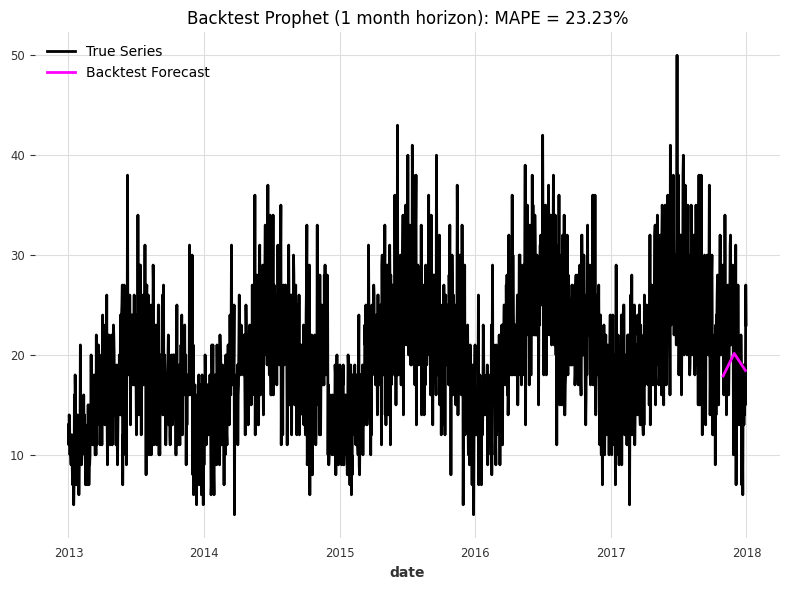

In [91]:
# Візуалізація
plt.figure(figsize=(8, 6))
ts_darts.plot(label="True Series", lw=2)
backtest.plot(label="Backtest Forecast", lw=2, color="magenta")
plt.title(f"Backtest Prophet (1 month horizon): MAPE = {backtest_mape:.2f}%")
plt.legend()
plt.tight_layout()
plt.show()

Всю варіантивність не вгадали, але виглядає непогано!

с17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

**Загальний підхід**

Отже, я вже побудувала процес для 1 айтему в 1 магазині. Наступний крок - масштабувати його на всі 500 серій (50 × 10).

Розбити дані на окремі TimeSeries для кожної пари (store_id, item_id).

Наприклад, створити словник:

`series_dict = {(store, item): TimeSeries.from_dataframe(...)}`

Можливі 2 стратегії:

- Локальні моделі (одна модель на серію)

Наприклад: Prophet, ARIMA, RNN тощо

Плюси: кастомізація під серію

Мінуси: довго, погано масштабується на 500 серій

- Глобальні моделі (одна модель на всі серії)

Наприклад: RNN/LSTM/Transformer (Darts), LightGBM з категоріями

Плюси: швидко, ефективно враховує схожість серій

Мінуси: складніші у налаштуванні

Особисто я спробувала б використати для масштабування на 500 серій глобальний підхід (LightGBM / LSTM / Transformer - які бачать усі серії одночасно).

